## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


In [7]:
start_rgb = (0.0, 1, 0.7) # low reward
end_rgb = (0.0, 0.2, 0.2) # high reward
cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])

# eval

ycstore/seed_0_varynode_10_epoch_51
ycstore/seed_0_varynode_25_epoch_51
ycstore/seed_0_varynode_40_epoch_51


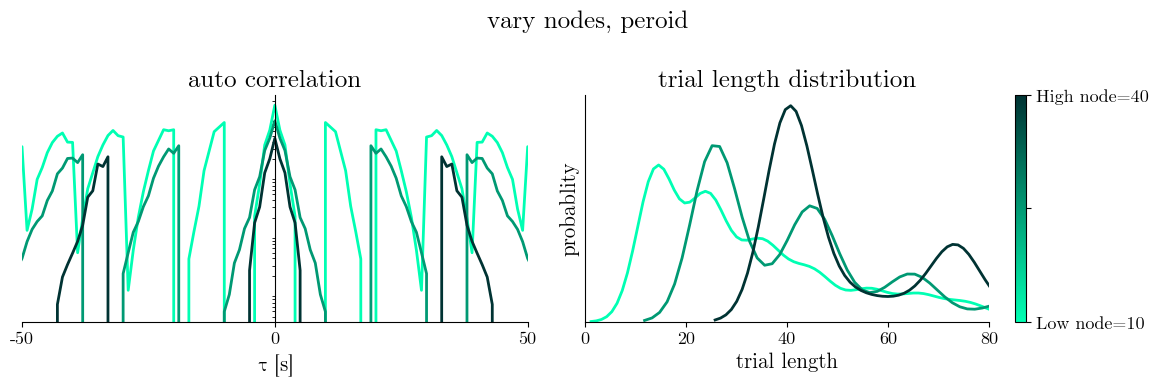

In [12]:

modelname = 'varynode'
iepoch=51
# training hyper params
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 333
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


# for food_reward_idx in range(len(food_reward_list)):
for food_reward_idx in [1]:
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))
        
        # autocorr. 
        for i, node in enumerate(node_list):
            env_param = [0, None, attcost, .25, facost, 0, 0]
            seed=0
            thismodel = f'seed_0_{modelname}_{node}'
            np.random.seed(seed)
            task = AFR2(spec={'agent': 
                                                {'lick_cost': env_param[0],
                                                'food_reward': env_param[1],
                                                'attention_cost_coeff': env_param[2],
                                                'attention_cost_temp': env_param[3],
                                                'penalty_cost': env_param[4],
                                                'iti_cost': env_param[5],
                                                'time_in_game_reward': env_param[6]},
                                        'experiment':{                              'no_signal_nodes':node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = np.array([.5,.7])
    
            # eval
            model = PPO.load(f'ycstore/{thismodel}_epoch_{iepoch}')
            print(f'ycstore/{thismodel}_epoch_{iepoch}')
            
            def eval_wrapper(a):
                episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                        num_steps=100000, deterministic=True)
                return episode

            with multiprocess.Pool(processes=6) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))

            # auto correlation
            att_seq_list = []
            for episode in all_episode_data:
                if episode['trial_food_reward_idx'] == food_reward_idx:
                    att_seq_list.append([float(elt[1])
                                        for elt in episode['actions']])
            # Sorting based on increasing trial length
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            # Choosing what range of trial lengths to use. Could modify to be more consistent.
            sequences = sorted_list_of_lists[-plot_no_episodes:]
            # autocorr
            autocorr, total_counts = empirical_autocorrelation(
                sequences, min_no_samples=1111)
            xs = np.arange(0, len(autocorr), 1)
            xs = xs-len(xs)//2
            ax1.plot(xs, autocorr,
                        label=f'node:{node}', color=cmap(np.linspace(0, 1, len(node_list)))[i])
            # trial len dist
            sns.kdeplot([len(a) for a in att_seq_list],
                        fill=False, bw_adjust=0.5, ax=ax2, color=cmap(np.linspace(0, 1, len(node_list)))[i])

        ax1.set_xlabel(r'$\tau$ [s]')
        ax1.set_title('auto correlation')
        ax1.set_xlim(-50,50)
        ax1.set_xticks([-50, 0, 50])
        ax1.set_yscale('log')
        ax1.set_yticks([])
        ax1.spines['left'].set_position('zero')

        ax2.set_xlabel('trial length')
        ax2.set_ylabel('probablity')
        ax2.set_yticks([])
        ax2.set_xlim(0, 80)
        ax2.set_title('trial length distribution')

        color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax2)
        ticks = [0, 0.5, 1]
        tick_labels = [f'Low node={node_list[0]}', '', f'High node={node_list[-1]}']
        color_bar.set_ticks(ticks)
        color_bar.set_ticklabels(tick_labels)


        # fig.suptitle(f'vary nodes, non peroid food \nreward={food_reward_list[food_reward_idx]:.0f}')
        fig.suptitle(f'vary nodes, peroid')
        plt.tight_layout()
        plt.show()